In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
# from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response import FullDetectorResponse, PointSourceResponse, GalacticResponse
from cosipy.response.functions import get_integrated_spectral_model
from cosipy.ts_map import FastNormFit, FastTSMap

# from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
from scipy.signal import find_peaks
from scipy.special import gammaln
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm
import mhealpy as hp

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['orange', 'limegreen', 'b', 'r']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

10:23:15 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=144168;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=655418;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=189120;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=280911;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=500988;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=140046;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=159977;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=561127;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

10:23:17 WARNING   No fermitools installed                                              ]8;id=858005;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=977743;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=991777;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=796605;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=208513;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=931940;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=426273;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=697000;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
data_obj = UnBinnedData('44Ti/inputs.yaml')

In [3]:
data = data_obj.get_dict_from_fits(input_fits = 'data/archive/dc4_mock_dataset_week_12_unbinned_data_filtered_with_SAAcut.fits')

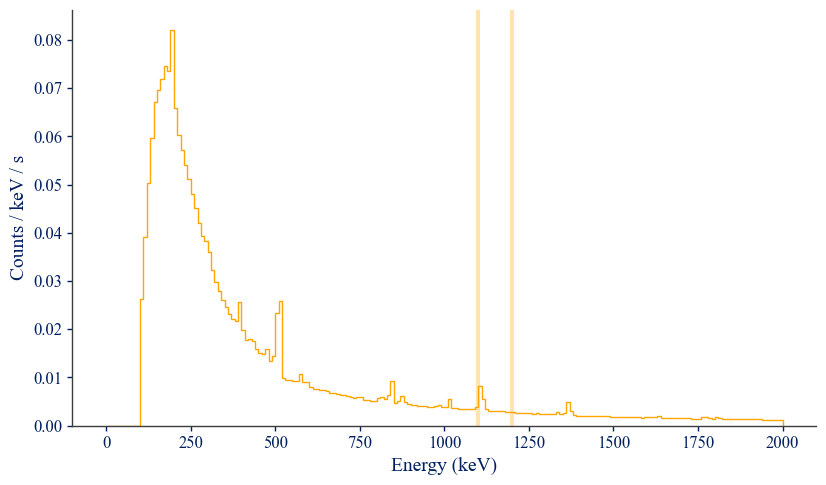

In [34]:
counts, bins = np.histogram(data['Energies'], bins=np.linspace(0, 2000, 201))
plt.stairs(counts / np.diff(bins) / (7 * 86400), bins)
plt.axvline(x=1100, c='orange', alpha=0.3)
plt.axvline(x=1200, c='orange', alpha=0.3)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts / keV / s')
plt.show()

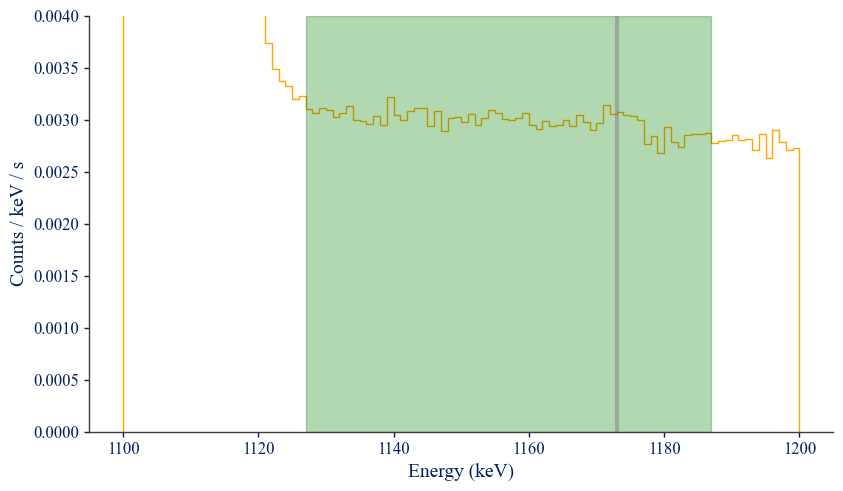

In [10]:
counts, bins = np.histogram(data['Energies'], bins=np.linspace(1100, 1200, 101))
plt.stairs(counts / np.diff(bins) / (7 * 86400), bins)
plt.axvspan(xmin=1127, xmax=1187, color='g', alpha=0.3)
plt.axvline(x=1173, c='gray', alpha=0.5)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts / keV / s')
plt.ylim(top=0.004)
plt.show()

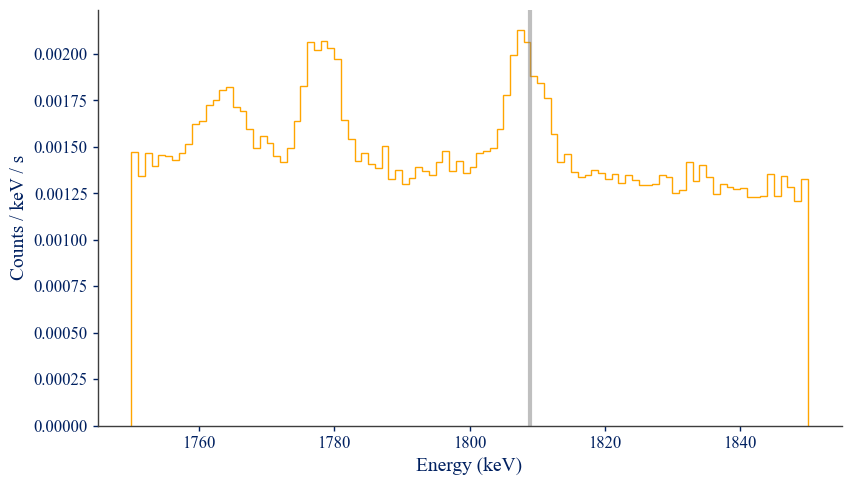

In [8]:
counts, bins = np.histogram(data['Energies'], bins=np.linspace(1750, 1850, 101))
plt.stairs(counts / np.diff(bins) / (7 * 86400), bins)
# plt.axvspan(xmin=1127, xmax=1187, color='g', alpha=0.3)
plt.axvline(x=1809, c='gray', alpha=0.5)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts / keV / s')
plt.show()

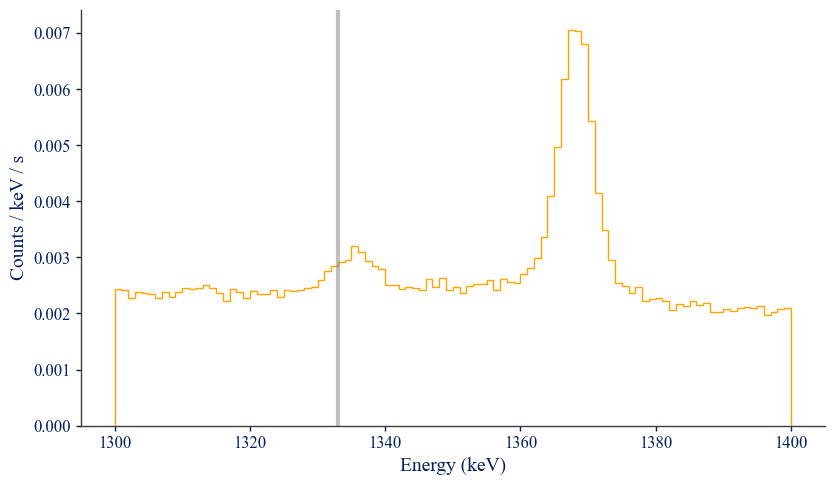

In [11]:
counts, bins = np.histogram(data['Energies'], bins=np.linspace(1300, 1400, 101))
plt.stairs(counts / np.diff(bins) / (7 * 86400), bins)
# plt.axvspan(xmin=1127, xmax=1187, color='g', alpha=0.3)
plt.axvline(x=1333, c='gray', alpha=0.5)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts / keV / s')
plt.show()

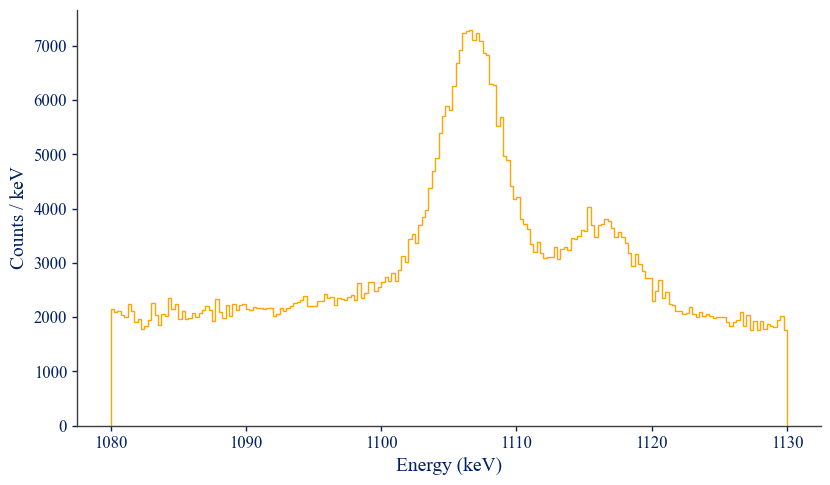

In [39]:
counts, bins = np.histogram(data['Energies'], bins=np.linspace(1080, 1130, 201))
plt.stairs(counts / np.diff(bins), bins)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts / keV')
plt.show()

### Background Model

In [3]:
bg_obj = BinnedData('44Ti/inputs.yaml')

In [4]:
bg_obj.load_binned_data_from_hdf5('data/backgrounds/binned/gal_DC4_bkg_Ti44_binned_smoothed_fwhm_10.0deg.hdf5')

In [47]:
bg = bg_obj.binned_data

(<Mollview: >, <matplotlib.image.AxesImage at 0x38d3288b0>)

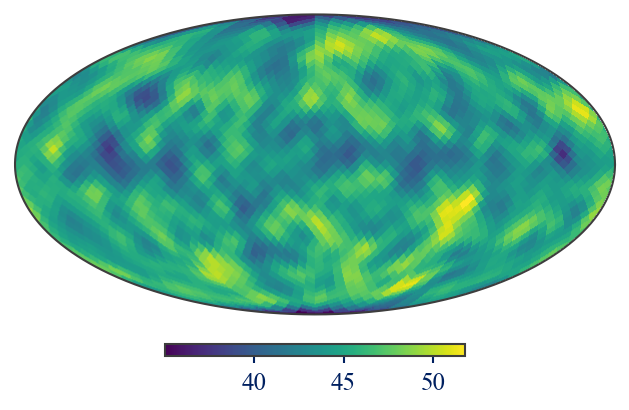

In [59]:
bg_obj.binned_data.project('PsiChi').plot()